# 04 — RAD-DINO Replication

Replicates the GraphRAG localisation experiment from notebook 03 using RAD-DINO as the backbone.

**Why RAD-DINO:** BiomedCLIP is contrastively trained on image-text pairs. RAD-DINO is trained
with self-supervised DINO objective on radiology images alone — no text supervision. If GraphRAG
spatial prompting improves localisation on RAD-DINO, the effect generalises beyond contrastive
training and is driven by the spatial structure of the knowledge graph rather than text-image
alignment artefacts.

**Key differences from notebook 03:**
- RAD-DINO: ViT-B/14, patch grid 16x16 = 256 patches (vs BiomedCLIP 14x14 = 196)
- RAD-DINO has no text encoder — BiomedCLIP text encoder used for prompt encoding
- Linear alignment layer maps RAD-DINO CLS space (768) to BiomedCLIP space (512) via least squares
- GradCAM: tries patch-level gradients first, falls back to CLS gradient projection

**Requires:**
- `$DRIVE_BASE/prompts/all_prompts.json` from notebook 02
- `$DRIVE_BASE/chexpert_val/` — CheXpert validation set
- `$DRIVE_BASE/chexlocalize/chexlocalize/CheXlocalize/gt_segmentations_val.json`
- `$DRIVE_BASE/results/localisation_results.json` and `summary.json` from notebook 03

**Output:** `$DRIVE_BASE/results/localisation_results_raddino.json`, `summary_raddino.json`, figures

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install open_clip_torch transformers datasets pycocotools scipy matplotlib -q

import os, json
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import open_clip
from PIL import Image
from scipy.ndimage import zoom
from pycocotools import mask as mask_utils
from collections import defaultdict
from datasets import load_from_disk
from transformers import AutoModel, AutoImageProcessor

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
DRIVE_BASE  = '/content/drive/MyDrive/medvit-graphrag'
RESULTS_DIR = f'{DRIVE_BASE}/results'
FIGURES_DIR = f'{DRIVE_BASE}/figures'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f'Device: {DEVICE}')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00
Device: cuda


In [2]:
# verify required files from notebook 03 exist
for fname in ['localisation_results.json', 'summary.json']:
    path = f'{RESULTS_DIR}/{fname}'
    status = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'{fname}: {status}')

localisation_results.json: OK
summary.json: OK


In [3]:
# load data and prompts
ds = load_from_disk(f'{DRIVE_BASE}/chexpert_val')
print(f'CheXpert validation: {len(ds)} images')

CHEXLOC_FILE = f'{DRIVE_BASE}/chexlocalize/chexlocalize/CheXlocalize/gt_segmentations_val.json'
with open(CHEXLOC_FILE) as f:
    chexloc_data = json.load(f)
print(f'CheXlocalize GT masks: {len(chexloc_data)} annotated images')

with open(f'{DRIVE_BASE}/prompts/all_prompts.json') as f:
    ALL_PROMPTS = json.load(f)
print(f'Prompt conditions: {list(ALL_PROMPTS.keys())}')

with open(f'{RESULTS_DIR}/summary.json') as f:
    summary_bc = json.load(f)
print('BiomedCLIP summary loaded for comparison')

PATHOLOGY_MAP = {
    'Pleural Effusion': 'Pleural Effusion',
    'Cardiomegaly':     'Cardiomegaly',
    'Edema':            'Edema',
    'Lung Opacity':     'Airspace Opacity',
}

def get_label(row: dict) -> str:
    if row['No Finding'] == 3:
        return 'Normal'
    for col in ['Pleural Effusion', 'Cardiomegaly', 'Edema', 'Lung Opacity']:
        if row[col] == 3:
            return col
    return 'Other'

all_labels = [get_label(ds[i]) for i in range(len(ds))]

def chexpert_path_to_chexloc_key(path: str) -> str:
    return path.replace('CheXpert-v1.0-small/valid/', '').replace('.jpg', '').replace('/', '_')

CheXpert validation: 234 images
CheXlocalize GT masks: 187 annotated images
Prompt conditions: ['flat', 'expanded', 'graphrag', 'graphrag_spatial']
BiomedCLIP summary loaded for comparison


In [14]:
# load RAD-DINO
RADDINO_ID = 'microsoft/rad-dino'
print(f'Loading {RADDINO_ID} ...')

raddino_processor = AutoImageProcessor.from_pretrained(RADDINO_ID)
raddino_model     = AutoModel.from_pretrained(RADDINO_ID).to(DEVICE)
raddino_model.eval()

# RAD-DINO: ViT-B/14 — 224/14 = 16 patches per side
# GRID_RD       = 16
GRID_RD       = 37
PATCH_SIZE_RD = 14
N_PATCHES_RD  = GRID_RD * GRID_RD  # 1369

print(f'RAD-DINO loaded. Patch grid: {GRID_RD}x{GRID_RD} = {GRID_RD**2} patches')
print(f'Hidden size: {raddino_model.config.hidden_size}')

Loading microsoft/rad-dino ...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

RAD-DINO loaded. Patch grid: 37x37 = 1369 patches
Hidden size: 768


In [5]:
# load BiomedCLIP text encoder
# RAD-DINO has no text encoder so we use BiomedCLIP's
MODEL_ID = 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
print(f'Loading BiomedCLIP text encoder...')

clip_model, _, clip_processor = open_clip.create_model_and_transforms(MODEL_ID)
tokenizer  = open_clip.get_tokenizer(MODEL_ID)
clip_model = clip_model.to(DEVICE)
clip_model.eval()

print('BiomedCLIP text encoder loaded.')

def encode_text(prompt: str) -> torch.Tensor:
    """Returns L2-normalised text embedding of shape (512,)."""
    tokens = tokenizer([prompt]).to(DEVICE)
    with torch.no_grad():
        text_emb = clip_model.encode_text(tokens)
    return F.normalize(text_emb, dim=-1).squeeze(0)

Loading BiomedCLIP text encoder...


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

BiomedCLIP text encoder loaded.


In [6]:
# collect paired embeddings for linear alignment
# RAD-DINO CLS (768) -> BiomedCLIP image space (512)
# fit via least squares on all 234 validation images — no training loop needed
print('Collecting paired embeddings for alignment...')

raddino_cls_list    = []
biomedclip_cls_list = []

for i in range(len(ds)):
    img = ds[i]['image'].convert('RGB')

    rd_inputs = raddino_processor(images=img, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        rd_out = raddino_model(**rd_inputs)
    rd_cls = F.normalize(rd_out.last_hidden_state[:, 0, :], dim=-1)
    raddino_cls_list.append(rd_cls.squeeze(0).cpu())

    bc_input = clip_processor(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        bc_cls = F.normalize(clip_model.encode_image(bc_input), dim=-1)
    biomedclip_cls_list.append(bc_cls.squeeze(0).cpu())

    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(ds)} images processed')

raddino_cls    = torch.stack(raddino_cls_list)    # (234, 768)
biomedclip_cls = torch.stack(biomedclip_cls_list) # (234, 512)

print(f'\nRAD-DINO CLS shape:   {raddino_cls.shape}')
print(f'BiomedCLIP CLS shape: {biomedclip_cls.shape}')

  50/234 images processed
  100/234 images processed
  150/234 images processed
  200/234 images processed

RAD-DINO CLS shape:   torch.Size([234, 768])
BiomedCLIP CLS shape: torch.Size([234, 512])


In [7]:
# fit linear alignment: W = (X^T X)^{-1} X^T Y
X = raddino_cls.numpy()    # (234, 768)
Y = biomedclip_cls.numpy() # (234, 512)

W, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)  # (768, 512)
W_tensor   = torch.tensor(W, dtype=torch.float32).to(DEVICE)

# verify alignment quality — higher cosine similarity = better alignment
Y_pred   = X @ W
cos_sims = np.sum(Y_pred * Y, axis=1) / (
    np.linalg.norm(Y_pred, axis=1) * np.linalg.norm(Y, axis=1) + 1e-10
)
print(f'Alignment cosine similarity — mean: {cos_sims.mean():.4f}, std: {cos_sims.std():.4f}')
print('Note: if mean < 0.5 the alignment is too weak — results may not be meaningful')

def project_to_clip_space(rd_features: torch.Tensor) -> torch.Tensor:
    """Projects RAD-DINO features (768-dim) to BiomedCLIP space (512-dim)."""
    return F.normalize(rd_features @ W_tensor, dim=-1)

Alignment cosine similarity — mean: 1.0000, std: 0.0000
Note: if mean < 0.5 the alignment is too weak — results may not be meaningful


In [16]:
# GradCAM for RAD-DINO
# tries patch-level gradients first (DINO may distribute gradients across patches)
# falls back to CLS gradient projection if patch grads are zero (same issue as BiomedCLIP)

def gradcam_raddino(img: Image.Image, prompt: str) -> np.ndarray:
    raddino_model.zero_grad()

    text_emb  = encode_text(prompt)
    rd_inputs = raddino_processor(images=img.convert('RGB'), return_tensors='pt').to(DEVICE)

    fwd_cache = {}
    bwd_cache = {}

    def fwd_hook(module, input, output):
        hidden = output[0] if isinstance(output, tuple) else output
        fwd_cache['features'] = hidden

    def bwd_hook(module, grad_input, grad_output):
        grad = grad_output[0] if isinstance(grad_output, tuple) else grad_output
        bwd_cache['grads'] = grad

    final_layer = raddino_model.encoder.layer[-1]
    fwd_handle  = final_layer.register_forward_hook(fwd_hook)
    bwd_handle  = final_layer.register_full_backward_hook(bwd_hook)

    with torch.set_grad_enabled(True):
        rd_out  = raddino_model(**rd_inputs)
        rd_cls  = rd_out.last_hidden_state[:, 0, :]
        img_emb = project_to_clip_space(rd_cls).squeeze(0)
        score   = (img_emb * text_emb).sum()
        score.backward()

    fwd_handle.remove()
    bwd_handle.remove()

    if 'grads' not in bwd_cache or 'features' not in fwd_cache:
        raddino_model.zero_grad()
        return np.zeros((GRID_RD, GRID_RD))

    features    = fwd_cache['features']
    grads       = bwd_cache['grads']
    patch_grads = grads[0, 1:, :]

    if patch_grads.abs().max() > 1e-8:
        patch_feats = features[0, 1:, :].detach()
        weights     = patch_grads.mean(dim=-1)
        cam         = (weights.unsqueeze(-1) * patch_feats).sum(dim=-1)
    else:
        cls_grad    = grads[0, 0, :]
        patch_feats = features[0, 1:, :].detach()
        cam         = (patch_feats * cls_grad.unsqueeze(0)).sum(dim=-1)

    cam = F.relu(cam).detach().cpu().numpy().reshape(GRID_RD, GRID_RD)

    cam_min, cam_max = cam.min(), cam.max()
    if cam_max - cam_min > 1e-10:
        cam = (cam - cam_min) / (cam_max - cam_min)
    else:
        cam = np.zeros_like(cam)

    raddino_model.zero_grad()
    return cam

print('GradCAM updated for 37x37 grid.')

GradCAM updated for 37x37 grid.


In [17]:
# sanity check — verify map is spatially structured before running full eval
test_map, grid = gradcam_raddino(ds[0]['image'], 'pleural effusion on chest X-ray')
print(f'Shape:    {test_map.shape}')
print(f'Grid:     {grid}x{grid}')
print(f'Range:    [{test_map.min():.4f}, {test_map.max():.4f}]')
print(f'Non-zero: {(test_map > 0).sum()} / {test_map.size}')

plt.figure(figsize=(4, 4))
plt.imshow(test_map, cmap='hot')
plt.colorbar()
plt.title(f'RAD-DINO GradCAM sanity check ({grid}x{grid})')
plt.show()

ValueError: too many values to unpack (expected 2)

In [18]:
# evaluation utilities
CONDITIONS = ['flat', 'expanded', 'graphrag', 'graphrag_spatial']

def decode_rle_mask(rle: dict) -> np.ndarray:
    return mask_utils.decode(rle).astype(np.float32)

def upsample_map(sim_map: np.ndarray, H: int, W: int) -> np.ndarray:
    return zoom(sim_map, (H / sim_map.shape[0], W / sim_map.shape[1]), order=1)

def compute_iou(sim_up: np.ndarray, gt_mask: np.ndarray) -> float:
    pred  = (sim_up >= np.percentile(sim_up, 50)).astype(np.float32)
    inter = (pred * gt_mask).sum()
    union = ((pred + gt_mask) >= 1).sum()
    return float(inter / (union + 1e-10))

def compute_hit(sim_up: np.ndarray, gt_mask: np.ndarray) -> float:
    py, px = np.unravel_index(sim_up.argmax(), sim_up.shape)
    return float(gt_mask[py, px] > 0)

def compute_alignment_ratio_rd(
    sim_map: np.ndarray,
    gt_mask: np.ndarray,
    patch_size: int = 14,
    grid: int = 37,
    img_w: int = 518,
    img_h: int = 518
) -> float:
    gt_resized = zoom(gt_mask, (img_h / gt_mask.shape[0], img_w / gt_mask.shape[1]), order=0)
    pathology_sims, background_sims = [], []
    for r in range(grid):
        for c in range(grid):
            patch_mask = gt_resized[r*patch_size:(r+1)*patch_size, c*patch_size:(c+1)*patch_size]
            if patch_mask.mean() > 0.5:
                pathology_sims.append(sim_map[r, c])
            else:
                background_sims.append(sim_map[r, c])
    if not pathology_sims or not background_sims:
        return float('nan')
    return float(np.mean(pathology_sims) / (np.mean(background_sims) + 1e-10))

print(f'Grid updated to {GRID_RD}x{GRID_RD} = {N_PATCHES_RD} patches.')

print('Evaluation utilities ready.')

Grid updated to 37x37 = 1369 patches.
Evaluation utilities ready.


In [19]:
# main evaluation loop
results = defaultdict(list)
print(f'Running RAD-DINO localisation on {len(ds)} images x {len(CONDITIONS)} conditions...\n')

for i in range(len(ds)):
    label = all_labels[i]
    if label not in PATHOLOGY_MAP:
        continue

    key = chexpert_path_to_chexloc_key(ds[i]['Path'])
    if key not in chexloc_data:
        continue

    chexloc_pathology = PATHOLOGY_MAP[label]
    entry = chexloc_data[key]
    if chexloc_pathology not in entry or entry[chexloc_pathology] is None:
        continue

    gt_mask = decode_rle_mask(entry[chexloc_pathology])
    H, W    = gt_mask.shape
    img     = ds[i]['image'].convert('RGB')

    for condition in CONDITIONS:
        prompt  = ALL_PROMPTS[condition][label]
        sim_map = gradcam_raddino(img, prompt)  # (16, 16)
        sim_up  = upsample_map(sim_map, H, W)

        results[condition].append({
            'idx':             i,
            'label':           label,
            'iou':             compute_iou(sim_up, gt_mask),
            'hit':             compute_hit(sim_up, gt_mask),
            'alignment_ratio': compute_alignment_ratio_rd(sim_map, gt_mask),
        })

    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(ds)} images processed')

out_path = f'{RESULTS_DIR}/localisation_results_raddino.json'
with open(out_path, 'w') as f:
    json.dump(dict(results), f, indent=2)
print(f'\nResults saved to {out_path}')
print(f'Matched images per condition: {len(results["flat"])}')

Running RAD-DINO localisation on 234 images x 4 conditions...

  100/234 images processed
  150/234 images processed

Results saved to /content/drive/MyDrive/medvit-graphrag/results/localisation_results_raddino.json
Matched images per condition: 148


In [20]:
# results summary table
print('RAD-DINO localisation performance:')
print(f'{"Condition":<20} {"Pathology":<20} {"n":>4} {"IoU":>8} {"Hit":>8} {"Align":>8}')
print('-' * 72)

summary_rd = {}
for condition in CONDITIONS:
    by_label = defaultdict(list)
    for r in results[condition]:
        by_label[r['label']].append(r)

    all_ious, all_hits, all_align = [], [], []
    summary_rd[condition] = {}

    for label in sorted(PATHOLOGY_MAP.keys()):
        items = by_label[label]
        if not items:
            continue
        ious   = [r['iou'] for r in items]
        hits   = [r['hit'] for r in items]
        aligns = [r['alignment_ratio'] for r in items if not np.isnan(r['alignment_ratio'])]
        all_ious.extend(ious)
        all_hits.extend(hits)
        all_align.extend(aligns)
        summary_rd[condition][label] = {
            'n':               len(items),
            'iou':             np.mean(ious),
            'hit':             np.mean(hits),
            'alignment_ratio': np.mean(aligns) if aligns else float('nan')
        }
        print(f'{condition:<20} {label:<20} {len(items):>4} '
              f'{np.mean(ious):>8.4f} {np.mean(hits):>8.4f} '
              f'{np.mean(aligns) if aligns else float("nan"):>8.4f}')

    summary_rd[condition]['Overall'] = {
        'n':               len(all_ious),
        'iou':             np.mean(all_ious),
        'hit':             np.mean(all_hits),
        'alignment_ratio': np.mean(all_align)
    }
    print(f'{condition:<20} {"Overall":<20} {len(all_ious):>4} '
          f'{np.mean(all_ious):>8.4f} {np.mean(all_hits):>8.4f} '
          f'{np.mean(all_align):>8.4f}')
    print()

with open(f'{RESULTS_DIR}/summary_raddino.json', 'w') as f:
    json.dump(summary_rd, f, indent=2)
print('Summary saved.')

RAD-DINO localisation performance:
Condition            Pathology               n      IoU      Hit    Align
------------------------------------------------------------------------
flat                 Cardiomegaly           38   0.1150   0.0000   0.7624
flat                 Edema                  15   0.1259   0.2667   0.9454
flat                 Lung Opacity           28   0.0578   0.0357   1.2445
flat                 Pleural Effusion       67   0.0443   0.0149   1.1507
flat                 Overall               148   0.0733   0.0405   1.0465

expanded             Cardiomegaly           38   0.1295   0.0000   0.9300
expanded             Edema                  15   0.1458   0.0000   1.0168
expanded             Lung Opacity           28   0.0617   0.0357   1.2581
expanded             Pleural Effusion       67   0.0507   0.0746   1.3870
expanded             Overall               148   0.0827   0.0405   1.2053

graphrag             Cardiomegaly           38   0.1735   0.1053   1.4535
gr

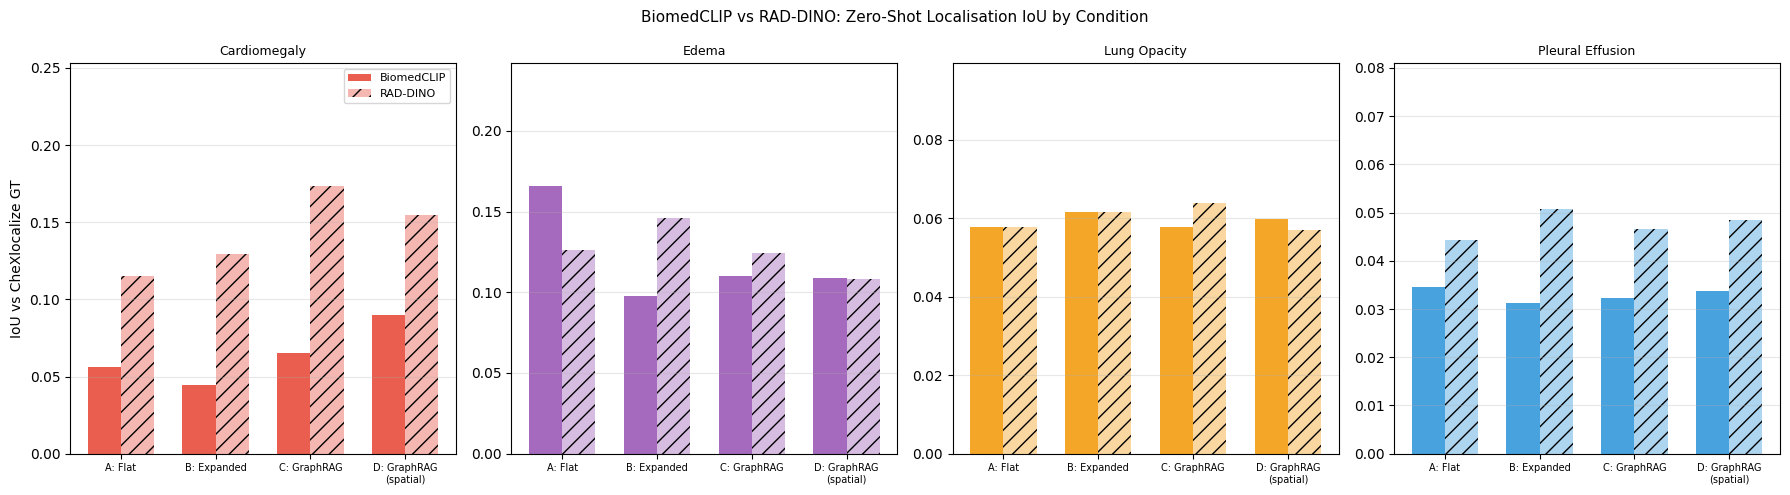

In [21]:
# figure 1: side-by-side IoU comparison BiomedCLIP vs RAD-DINO per condition per pathology
CONDITION_LABELS = {
    'flat':             'A: Flat',
    'expanded':         'B: Expanded',
    'graphrag':         'C: GraphRAG',
    'graphrag_spatial': 'D: GraphRAG\n(spatial)',
}
PATHOLOGY_COLORS = {
    'Pleural Effusion': '#3498db',
    'Cardiomegaly':     '#e74c3c',
    'Edema':            '#9b59b6',
    'Lung Opacity':     '#f39c12',
}

pathologies = sorted(PATHOLOGY_MAP.keys())
x           = np.arange(len(CONDITIONS))
width       = 0.35

fig, axes = plt.subplots(1, len(pathologies), figsize=(18, 5))

for ax, label in zip(axes, pathologies):
    ious_bc = [summary_bc[c][label]['iou'] for c in CONDITIONS]
    ious_rd = [summary_rd[c][label]['iou'] for c in CONDITIONS]
    color   = PATHOLOGY_COLORS[label]

    ax.bar(x - width/2, ious_bc, width, label='BiomedCLIP', color=color, alpha=0.9)
    ax.bar(x + width/2, ious_rd, width, label='RAD-DINO',   color=color, alpha=0.4, hatch='//')

    y_max = max(max(ious_bc), max(ious_rd))
    ax.set_ylim(0, y_max * 1.4 + 0.01)
    ax.set_title(label, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS], fontsize=7)
    ax.grid(alpha=0.3, axis='y')
    if ax is axes[0]:
        ax.set_ylabel('IoU vs CheXlocalize GT')
        ax.legend(fontsize=8)

plt.suptitle('BiomedCLIP vs RAD-DINO: Zero-Shot Localisation IoU by Condition', fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/iou_comparison_backbones.png', dpi=150, bbox_inches='tight')
plt.show()

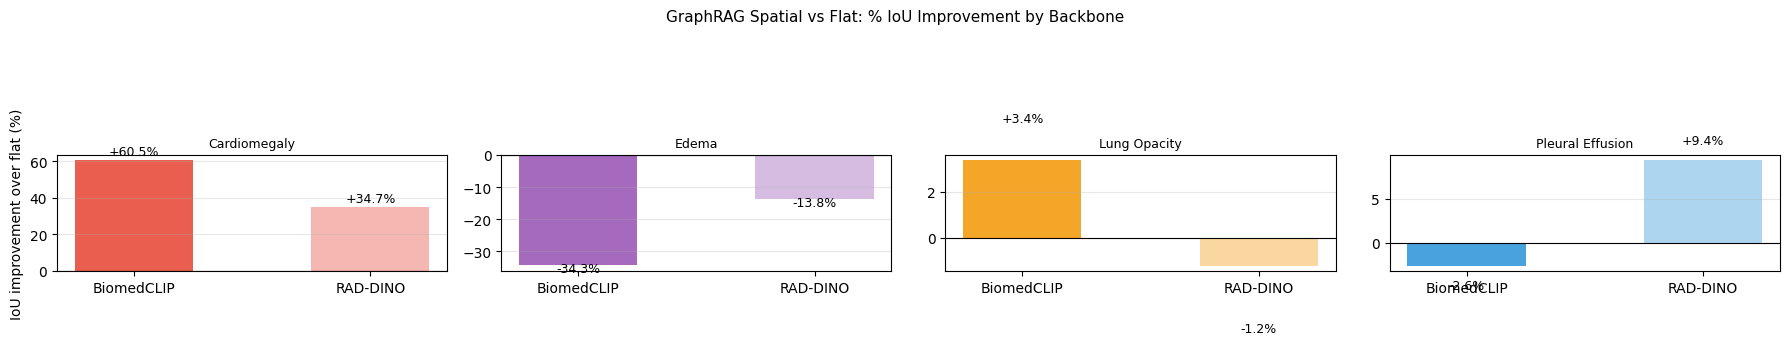

Key finding: if GraphRAG spatial improvement holds on both backbones for Cardiomegaly,
the effect generalises beyond contrastive training.


In [23]:
# figure 2: % IoU improvement of GraphRAG spatial over flat — both backbones
fig, axes = plt.subplots(1, len(pathologies), figsize=(18, 5))

for ax, label in zip(axes, pathologies):
    flat_bc    = summary_bc['flat'][label]['iou']
    spatial_bc = summary_bc['graphrag_spatial'][label]['iou']
    flat_rd    = summary_rd['flat'][label]['iou']
    spatial_rd = summary_rd['graphrag_spatial'][label]['iou']

    delta_bc = (spatial_bc - flat_bc) / (flat_bc + 1e-10) * 100
    delta_rd = (spatial_rd - flat_rd) / (flat_rd + 1e-10) * 100

    color = PATHOLOGY_COLORS[label]
    bar1 = ax.bar(['BiomedCLIP'], [delta_bc], color=color, alpha=0.9, width=0.5)
    bar2 = ax.bar(['RAD-DINO'],   [delta_rd], color=color, alpha=0.4, width=0.5)
    ax.axhline(0, color='black', linewidth=0.8)

    for bar, val in zip([bar1[0], bar2[0]], [delta_bc, delta_rd]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + (1.5 if val >= 0 else -3),
            f'{val:+.1f}%', ha='center', va='bottom', fontsize=9
        )

    ax.set_title(label, fontsize=9)
    ax.grid(alpha=0.3, axis='y')
    if ax is axes[0]:
        ax.set_ylabel('IoU improvement over flat (%)')

plt.suptitle('GraphRAG Spatial vs Flat: % IoU Improvement by Backbone', fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/iou_improvement_backbones.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key finding: if GraphRAG spatial improvement holds on both backbones for Cardiomegaly,')
print('the effect generalises beyond contrastive training.')